In [1]:
# Import necessary libraries
!pip install -q datasets transformers accelerate

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

SEED = 42
MODEL_NAME = "bert-base-uncased"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# Load and split the IMDb dataset into training, validation, and test sets
def load_and_split_data(train_size=5000, test_size=2000):

    imdb_data = load_dataset("stanfordnlp/imdb")

    train = (
        imdb_data["train"]
        .shuffle(seed=SEED)
        .select(range(train_size))
    )

    test = (
        imdb_data["test"]
        .shuffle(seed=SEED)
        .select(range(test_size))
    )

    train_val_split = train.train_test_split(
        test_size=0.20,
        seed=SEED,
        stratify_by_column="label"
    )

    return (
        train_val_split["train"],
        train_val_split["test"],
        test
    )


train_set, validation_set, test_set = load_and_split_data()

print("Training reviews:", len(train_set))
print("Validation reviews:", len(validation_set))
print("Testing reviews:", len(test_set))

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training reviews: 4000
Validation reviews: 1000
Testing reviews: 2000


In [3]:
# Explore the dataset
train_df = train_set.to_pandas()
validation_df = validation_set.to_pandas()
test_df = test_set.to_pandas()

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Testing shape:", test_df.shape)

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nTraining label counts:")
print(train_df["label"].value_counts().sort_index())

print("\nExample review:")
print(train_df.iloc[0]["text"][:500])

print("\nLabel:", train_df.iloc[0]["label"])
print("Sentiment:", "Positive" if train_df.iloc[0]["label"] == 1 else "Negative")

Training shape: (4000, 2)
Validation shape: (1000, 2)
Testing shape: (2000, 2)

Missing values:
text     0
label    0
dtype: int64

Training label counts:
label
0    1995
1    2005
Name: count, dtype: int64

Example review:
If scientists behaved in a way that H.G. Wells was confident they would in the future, history wouldn't quite have turned out the way it did in Things To Come. Were almost 80 years past the point that Wells wrote The Shape Of Things To Come on which this film is based and no closer to the world he describes than before, in some ways farther away.<br /><br />Though such well known players as Raymond Massey, Ralph Richardson, and Cedric Hardwicke are in the cast, they're more caricatures than real

Label: 1
Sentiment: Positive


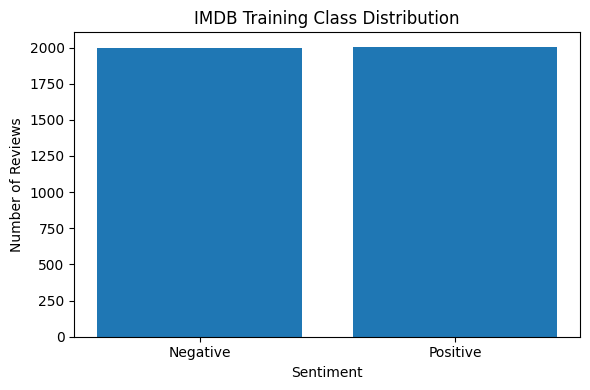

In [4]:
# Plot the class distribution of the training data
label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative", "Positive"], label_counts.values)

plt.title("IMDB Training Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [5]:
# Calculate the model evaluation metrics
def calculate_metrics(true_labels, predicted_labels):

    return {
        "Accuracy": accuracy_score(true_labels, predicted_labels),
        "Precision": precision_score(
            true_labels,
            predicted_labels,
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predicted_labels,
            zero_division=0
        ),
        "F1-score": f1_score(
            true_labels,
            predicted_labels,
            zero_division=0
        )
    }

In [6]:
# Train the Logistic Regression model
def train_baseline(train_texts, train_labels, test_texts):

    TFIDFV = TfidfVectorizer(
        max_features=10000,
        stop_words="english",
        ngram_range=(1, 2)
    )

    train_features = TFIDFV.fit_transform(train_texts)
    test_features = TFIDFV.transform(test_texts)

    LR_model = LogisticRegression(
        max_iter=1000,
        random_state=SEED
    )

    LR_model.fit(train_features, train_labels)
    LR_predictions = LR_model.predict(test_features)

    return LR_model, TFIDFV, LR_predictions


LR_model, TFIDFV, LR_predictions = train_baseline(
    train_df["text"],
    train_df["label"],
    test_df["text"]
)

In [7]:
# Evaluate the Logistic Regression model
LR_metrics = calculate_metrics(
    test_df["label"],
    LR_predictions
)

print("Logistic Regression Results:")

for metric, value in LR_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_df["label"],
        LR_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

Logistic Regression Results:
Accuracy: 0.8505
Precision: 0.8360
Recall: 0.8720
F1-score: 0.8536

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.83      0.85      1000
    Positive       0.84      0.87      0.85      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [8]:
# Tokenize the reviews for BERT training
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 256


def tokenize_reviews(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


tokenized_train = train_set.map(
    tokenize_reviews,
    batched=True
)

tokenized_validation = validation_set.map(
    tokenize_reviews,
    batched=True
)

tokenized_test = test_set.map(
    tokenize_reviews,
    batched=True
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [9]:
# Load the pre-trained BERT model and evaluation metrics
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={
        0: "Negative",
        1: "Positive"
    },
    label2id={
        "Negative": 0,
        "Positive": 1
    }
)


def compute_bert_metrics(evaluation_output):

    logits, labels = evaluation_output
    predictions = np.argmax(logits, axis=-1)

    metrics = calculate_metrics(labels, predictions)

    return {
        "accuracy": metrics["Accuracy"],
        "precision": metrics["Precision"],
        "recall": metrics["Recall"],
        "f1": metrics["F1-score"]
    }

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
# Set training parameters
training_args = TrainingArguments(
    output_dir="./bert_imdb_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,
    report_to="none",
    seed=SEED,

    fp16=torch.cuda.is_available()
)


trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
    compute_metrics=compute_bert_metrics
)

In [11]:
# Train the BERT model
training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.383412,0.401387,0.870000,0.828319,0.934132,0.878049
2,0.190075,0.437685,0.879000,0.886179,0.870259,0.878147


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

In [12]:
# Evaluate the BERT model
bert_output = trainer.predict(tokenized_test)

bert_predictions = np.argmax(
    bert_output.predictions,
    axis=-1
)

bert_metrics = calculate_metrics(
    test_df["label"],
    bert_predictions
)

print("Fine-Tuned BERT Results:")

for metric, value in bert_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_df["label"],
        bert_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

Fine-Tuned BERT Results:
Accuracy: 0.9095
Precision: 0.9058
Recall: 0.9140
F1-score: 0.9099

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91      1000
    Positive       0.91      0.91      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [13]:
# Compare the performance of both models
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **LR_metrics
    },
    {
        "Model": "Fine-tuned BERT",
        **bert_metrics
    }
])

results_df = results_df.round(4)

print("Logistic Regression VS Fine-Tuned BERT:")
display(results_df)

Logistic Regression VS Fine-Tuned BERT:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8505,0.8360,0.872,0.8536
1,Fine-tuned BERT,0.9095,0.9058,0.914,0.9099


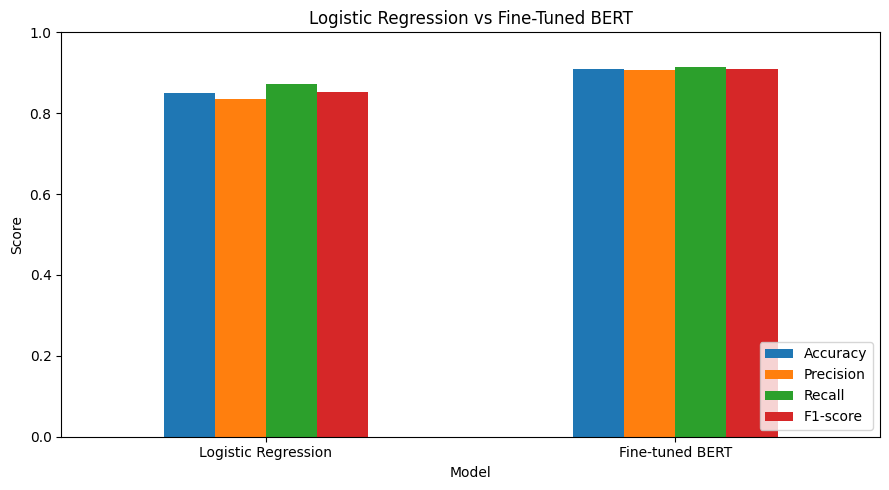

In [14]:
# Plot the performance comparison of both models
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Logistic Regression vs Fine-Tuned BERT")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()